# 07 - Hybrid QGFDA End-to-End

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Runs the full **Quantum-Gated Fraud Detection Architecture (QGFDA)**: classical fast path ->
uncertainty gate -> quantum path (on routed transactions only) -> risk fusion -> cost-sensitive
APPROVE/REVIEW/BLOCK decision engine. This is the project's primary research contribution.

In [2]:
from src.data.loaders import load_synthetic
from src.data.preprocessing import clean_dataframe, fit_transform_split, infer_feature_types, random_split
from src.classical.xgboost_model import XGBoostModel
from src.quantum.vqc_model import VQCModel
from src.hybrid.qgfda import QGFDA, QGFDAConfig
from src.hybrid.cost_sensitive_decision import CostModel

ds = load_synthetic("ulb", n_samples=6000, random_state=42)
frame = clean_dataframe(ds.frame, ds.target)
numeric, categorical = infer_feature_types(frame, ds.target, ds.categorical_features)
splits = random_split(frame, ds.target, test_size=0.2, validation_size=0.15, random_state=42)
X_train, X_others, transformer, meta = fit_transform_split(
    splits["train"], {"val": splits["val"], "test": splits["test"]}, ds.target, numeric, categorical
)
y_train = splits["train"][ds.target].values
y_val = splits["val"][ds.target].values
y_test = splits["test"][ds.target].values

config = QGFDAConfig(
    quantum_feature_indices=[0, 1, 2],
    gate_threshold=0.80, risk_band=(0.15, 0.85), max_quantum_fraction=0.25,
    fusion_method="weighted", fusion_weights={"classical": 0.6, "quantum": 0.4},
    cost_model=CostModel(fraud_loss=500, false_positive_cost=25, review_cost=5),
    threshold_search_grid_points=30, quantum_train_sample_size=150, random_state=42,
)
classical_model = XGBoostModel(calibrate=False)
quantum_model = VQCModel(num_qubits=3, backend="simulator", shots=256, seed=42,
                          optimizer="cobyla", optimizer_maxiter=40)

qgfda = QGFDA(classical_model, quantum_model, config)
qgfda.fit(X_train, y_train, X_others["val"], y_val)
result = qgfda.evaluate(X_others["test"], y_test)
print(result["binary_metrics"])
print(result["decision_summary"])
print(f"quantum_fraction = {result['quantum_fraction']:.3%}")


2026-09-14 01:44:23 | INFO     | hybrid.qgfda | Fitting classical fast path on 3900 training rows.


2026-09-14 01:44:25 | INFO     | hybrid.qgfda | Fitting quantum path on 150 sampled training rows (3 qubits).


2026-09-14 01:45:07 | INFO     | hybrid.qgfda | Optimized decision thresholds: ThresholdConfig(review_threshold=0.24137931034482757, block_threshold=0.24137931034482757, expected_loss=500, search_grid_points=30)


ClassificationMetrics(pr_auc=0.8438669494843981, roc_auc=0.9931338099277031, average_precision=0.8458307345212107, precision=0.9285714285714286, recall=0.6190476190476191, f1=0.7428571428571429, fpr=0.0008481764206955047, fnr=0.38095238095238093, mcc=0.7548989072751616, brier_score=0.0074342098262001185, expected_loss=4025, n_samples=1200, n_positive=21, threshold=0.24137931034482757, tp=13, fp=1, tn=1178, fn=8)
DecisionSummary(n_approve=1186, n_review=0, n_block=14, approve_rate=0.9883333333333333, review_rate=0.0, block_rate=0.011666666666666667, expected_loss=4025)
quantum_fraction = 0.667%


In [3]:
frame_out = result["predictions"].to_frame()
frame_out.head(10)


,transaction_id,amount,classical_risk,quantum_risk,final_risk,routed_to_quantum,decision
0,TXN-00000000,NaN,0.000100,NaN,0.000100,False,APPROVE
1,TXN-00000001,NaN,0.000216,NaN,0.000216,False,APPROVE
2,TXN-00000002,NaN,0.000024,NaN,0.000024,False,APPROVE
3,TXN-00000003,NaN,0.000177,NaN,0.000177,False,APPROVE
4,TXN-00000004,NaN,0.001834,NaN,0.001834,False,APPROVE
5,TXN-00000005,NaN,0.000102,NaN,0.000102,False,APPROVE
6,TXN-00000006,NaN,0.004439,NaN,0.004439,False,APPROVE
7,TXN-00000007,NaN,0.000015,NaN,0.000015,False,APPROVE
8,TXN-00000008,NaN,0.003703,NaN,0.003703,False,APPROVE
9,TXN-00000009,NaN,0.000078,NaN,0.000078,False,APPROVE


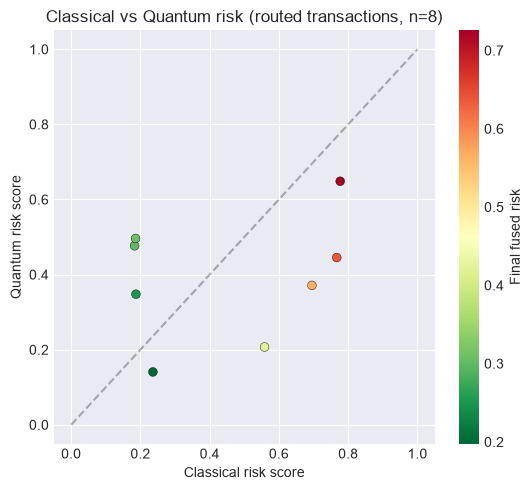

In [4]:
routed = frame_out[frame_out["routed_to_quantum"]]
fig, ax = plt.subplots(figsize=(5.5, 5))
if len(routed):
    ax.scatter(routed["classical_risk"], routed["quantum_risk"], c=routed["final_risk"],
               cmap="RdYlGn_r", s=40, edgecolor="k", linewidth=0.3)
    fig.colorbar(ax.collections[0], ax=ax, label="Final fused risk")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Classical risk score"); ax.set_ylabel("Quantum risk score")
ax.set_title(f"Classical vs Quantum risk (routed transactions, n={len(routed)})")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\07_classical_vs_quantum_risk.png")
plt.show()


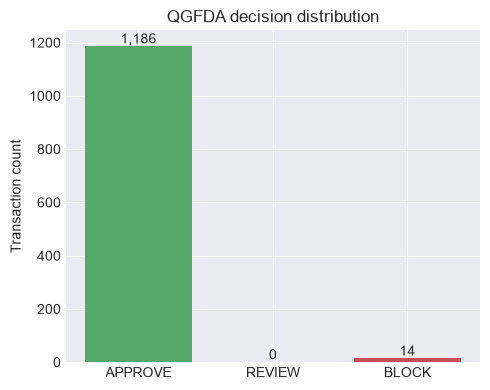

In [5]:
decision_counts = frame_out["decision"].value_counts().reindex(["APPROVE", "REVIEW", "BLOCK"]).fillna(0)
fig, ax = plt.subplots(figsize=(5, 4))
colors = {"APPROVE": "#55A868", "REVIEW": "#DD8452", "BLOCK": "#C44E52"}
ax.bar(decision_counts.index, decision_counts.values, color=[colors[d] for d in decision_counts.index])
for i, v in enumerate(decision_counts.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
ax.set_ylabel("Transaction count")
ax.set_title("QGFDA decision distribution")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\07_decision_distribution.png")
plt.show()


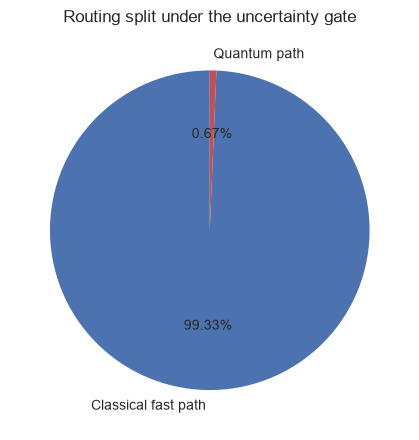

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
frac = result["quantum_fraction"]
ax.pie([1 - frac, frac], labels=["Classical fast path", "Quantum path"],
       colors=["#4C72B0", "#C44E52"], autopct="%1.2f%%", startangle=90)
ax.set_title("Routing split under the uncertainty gate")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\07_routing_split.png")
plt.show()
